In this notebook CNN_crossViT Seamese network model with triplet loss for handwriting author verification trained. 

First, import training dataset

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl
From (redirected): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl&confirm=t&uuid=580b90b9-179d-4403-8bca-7340821854e8
To: /content/all_data_3.zip
100% 1.76G/1.76G [00:22<00:00, 80.0MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_3']

In [3]:
DATA_ROOT = "/kaggle/working/all_data_3"

Importing test and val .pkl files

In [4]:
val_dataset_file="1aJ87RzaTUVQcC8CIT_7xiPWQGFn0pAOx"
output_name = "val_triplet.pkl"

!gdown --id {val_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1aJ87RzaTUVQcC8CIT_7xiPWQGFn0pAOx
To: /content/val_triplet.pkl
100% 178k/178k [00:00<00:00, 4.91MB/s]


In [5]:
test_dataset_file="17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF"
output_name = "test_pairs.pkl"

!gdown --id {test_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1yOuLeMx_P-sMsnXCO2skBFKs3SknchyJ
To: /content/test_triplet.pkl
100% 126k/126k [00:00<00:00, 3.47MB/s]


In [6]:
DATA_ROOT_val_pairs = "/kaggle/working/val_triplet.pkl"
DATA_ROOT_test_pairs = "/kaggle/working/test_pairs.pkl"

Importing required modules

In [7]:
!pip install torchvision

In [8]:
!pip install timm

In [9]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, LinearLR, CosineAnnealingLR, SequentialLR
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import pickle

from torchvision.models import resnet18, ResNet18_Weights  


In [10]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Now let's creating TripletDataset class which takes root to folder with training domain and creates triplets 
This dataset implements triplet sampling for handwriting verification across multiple datasets (IAM, CEDAR, Bengali, Hindi).

What it does:
Generates triplets (anchor, positive, negative) for training a Siamese network with triplet loss.

How it works:
Two sampling strategies (controlled by iam_ratio):

IAM dataset (handwriting lines) - iam_ratio=0.5 (50% of samples):

Anchor & Positive: Two different handwritten samples from the SAME author

Negative: A sample from a DIFFERENT author

Signature datasets (CEDAR, Bengali, Hindi):

Anchor & Positive: Two genuine signatures from the SAME author

Negative: A FORGERY of the same author (skilled forgery)

Key features:
Automatically scans folder structures for each dataset

Validates images before loading

Supports train/validation split via authors_list parameter

Falls back to available data if primary sampling fails

Returns 3 augmented images ready for triplet loss training

Typical output shape:
(anchor, positive, negative) where each is a tensor [C, H, W] (grayscale, transformed).

In [11]:
class TripletDataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Triplet Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Returns triplets (anchor, positive, negative) where:
        - IAM: anchor + positive = same author, negative = different author
        - Signature datasets: anchor + positive = two genuine of same author, negative = forgery of same author

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of triplets per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        # === Scan IAM folder ===
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        #Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        #Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        #Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        # Filter by authors_list if provided
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
            self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
            self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
            self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
            self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))

    def __len__(self):
        return self.size

    def _get_iam_triplet(self):
        """IAM triplet: anchor + positive = same author, negative = different author"""
        if len(self.iam_authors) < 1:
            return None, None, None

        author = random.choice(self.iam_authors)
        images = self.iam_data[author]
        if len(images) < 2:
            return None, None, None

        # Anchor and Positive: two different images from same author
        anchor_path, positive_path = random.sample(images, 2)

        # Negative: different author
        other_authors = [a for a in self.iam_all_authors if a != author]
        if not other_authors:
            return None, None, None

        negative_author = random.choice(other_authors)
        negative_path = random.choice(self.iam_data[negative_author])

        return anchor_path, positive_path, negative_path

    def _get_signature_triplet(self, original_dict, forgery_dict, authors_with_forgery):
        """Signature triplet: anchor + positive = two genuines of same author, negative = forgery of same author"""
        if not authors_with_forgery:
            return None, None, None

        author = random.choice(authors_with_forgery)
        original_images = original_dict[author]
        forgery_images = forgery_dict[author]

        if len(original_images) < 2 or not forgery_images:
            return None, None, None

        # Anchor and Positive: two different genuine images
        anchor_path, positive_path = random.sample(original_images, 2)

        # Negative: forgery of the same author
        negative_path = random.choice(forgery_images)

        return anchor_path, positive_path, negative_path

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio

        anchor_path, positive_path, negative_path = None, None, None

        if use_iam and self.iam_authors:
            anchor_path, positive_path, negative_path= self._get_iam_triplet()

        if anchor_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            anchor_path, positive_path, negative_path = self._get_signature_triplet(original_dict, forgery_dict, authors_with_forgery)

        if anchor_path is None:
            # Fallback: try IAM
            if self.iam_authors:
                anchor_path, positive_path, negative_path = self._get_iam_triplet()
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                anchor_path, positive_path, negative_path = self._get_signature_triplet(original_dict, forgery_dict, authors_with_forgery)

        # Load images
        anchor = Image.open(anchor_path).convert('L')
        positive = Image.open(positive_path).convert('L')
        negative = Image.open(negative_path).convert('L')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

In [13]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


In [14]:
train_transform = T.Compose([
    T.Resize((240, 240)),  #use 240*240 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((240, 240)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((240, 240)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [15]:
train_dataset = TripletDataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=5000,
    authors_list=train_authors
)



TripletDataset initialized:
  IAM: 453 authors, 6772 images
  CEDAR: 35 authors, 840 genuine, 840 forgery
  Bengali: 74 authors
  Hindi: 114 authors
  IAM ratio: 50%


Now let's create val and test-pairs dataset

In [ ]:
class SavedTestPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка

test_dataset = SavedTestPairsDataset('test_pairs.pkl', transform=test_transform)

In [16]:
class SavedTripletDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, img3_path = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')
        img3 = Image.open(img3_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
            img3 = self.transform(img3)

        return img1, img2, img3

In [17]:


# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка
val_dataset = SavedTripletDataset('val_triplet.pkl', transform=val_transform)

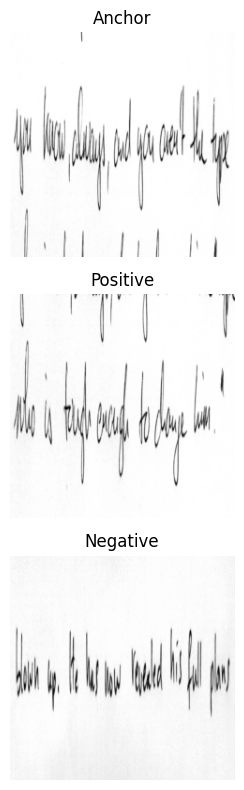

In [18]:
#Let's look at an example of data
anchor, positive, negative= test_dataset[1]

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.imshow(anchor[0], cmap='gray')
plt.title(f"Anchor")
plt.axis('off')

plt.subplot(3, 1, 2)
plt.imshow(positive[0], cmap='gray')
plt.title("Positive")
plt.axis('off')

plt.subplot(3, 1, 3)
plt.imshow(negative[0], cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [19]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

This code implements a hybrid CNN-Vision Transformer model for handwriting and signature verification using triplet loss.

Architecture Overview:

The model combines two parallel feature extractors:

CNN Branch (ResNet-18): Extracts local features (pen strokes, texture patterns) from grayscale images

CrossViT Branch: Processes global context using a CrossViT Base 240 transformer

Feature Processing:

CNN features are passed through a Feature Pyramid Network (FPN) to capture multi-scale information from three ResNet layers (64, 128, 256 channels)

CrossViT features are extracted from the same input image after adapting the model to grayscale

Fusion module combines both features (192 + 768 = 960 dimensions) through a feed-forward network with BatchNorm, Dropout (0.6), and produces L2-normalized embeddings (default 512 dimensions)

Key Design Choices:

Grayscale adaptation: Both ResNet and CrossViT pretrained on RGB are adapted to 1-channel input by averaging RGB weights

Selective freezing: Partial freeze mode freezes early CNN layers and keeps only last 4 transformer blocks trainable (12 total blocks)

Metric learning: Returns normalized embeddings optimized for triplet loss with Euclidean distance

Forward Methods:

forward_one(x): Single image → embedding

forward(anchor, positive, negative): Processes triplets for training

predict_pair(img1, img2): Inference for writer verification

Purpose: Creates a robust writer verification system that leverages both local CNN features and global transformer context, trained with triplet margin loss.

In [20]:
def adapt_conv2d_to_grayscale(module):
    """Adapts Conv2d layer from 3 channels to 1 channel"""
    if isinstance(module, nn.Conv2d) and module.in_channels == 3:
        new_conv = nn.Conv2d(
            1, module.out_channels,
            kernel_size=module.kernel_size,
            stride=module.stride,
            padding=module.padding,
            dilation=module.dilation,
            groups=module.groups,
            bias=module.bias is not None
        )
        with torch.no_grad():
            new_conv.weight.data = module.weight.data.mean(dim=1, keepdim=True)
            if module.bias is not None:
                new_conv.bias.data = module.bias.data
        module.in_channels = 1
        module.weight.data = new_conv.weight.data
        if module.bias is not None:
            module.bias.data = new_conv.bias.data
        return True
    return False


def adapt_model_to_grayscale(model):
    """Adapts ALL Conv2d layers of the model to grayscale"""
    adapted_count = 0
    for module in model.modules():
        if adapt_conv2d_to_grayscale(module):
            adapted_count += 1
    return model


class CNNCrossViTTriplet(nn.Module):
    """
    CNN-CrossViT hybrid model for Triplet Loss training.
    Input: 240x240 grayscale images (anchor, positive, negative).
    Uses CrossViT Base 240 for balanced accuracy/speed.
    NO classification head - pure metric learning approach.
    """
    def __init__(self, embedding_size=512, pretrained=True, freeze_backbone='partial'):
        super(CNNCrossViTTriplet, self).__init__()

        # 1. CNN BRANCH (ResNet-18) 
        if pretrained:
            resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        else:
            resnet = resnet18(weights=None)

        original_conv1 = resnet.conv1
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            resnet.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        self.cnn_conv1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.cnn_layer1 = resnet.layer1    # 64 channels (ResNet-18)
        self.cnn_layer2 = resnet.layer2    # 128 channels
        self.cnn_layer3 = resnet.layer3    # 256 channels

        # FPN layers - adjusted for ResNet-18 channel dimensions
        self.fpn_lateral = nn.ModuleList([
            nn.Conv2d(64, 64, 1),    # layer1: 64 → 64
            nn.Conv2d(128, 64, 1),   # layer2: 128 → 64
            nn.Conv2d(256, 64, 1)    # layer3: 256 → 64
        ])
        self.fpn_output = nn.ModuleList([
            nn.Conv2d(64, 64, 3, padding=1),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.Conv2d(64, 64, 3, padding=1)
        ])

        self.crossvit = timm.create_model('crossvit_base_240', pretrained=pretrained, num_classes=0)

        adapt_model_to_grayscale(self.crossvit)

        cnn_out_dim = 64 * 3  # 192
        crossvit_out_dim = self.crossvit.num_features  # 768 for crossvit_base_240

        #  3. FUSION
        self.fusion = nn.Sequential(
            nn.Linear(cnn_out_dim + crossvit_out_dim, 512),  # 192+768=960 → 512
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.6),
            nn.Linear(512, embedding_size),
            nn.BatchNorm1d(embedding_size)
        )

        self.embedding_size = embedding_size

        # 4. FREEZE LAYERS 
        self._freeze_layers(freeze_backbone)

        # Statistics
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"CNN-CrossViT Triplet initialized. Embedding size: {embedding_size}")
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

    def _freeze_layers(self, freeze_mode):
        if freeze_mode == 'partial':
            # CNN Branch - freeze early layers
            for param in self.cnn_conv1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer2.parameters():
                param.requires_grad = False

            self._freeze_crossvit_transformer_blocks(num_trainable_blocks=4)

        elif freeze_mode == 'full':
            # Freeze all CNN
            for param in self.cnn_conv1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer2.parameters():
                param.requires_grad = False
            for param in self.cnn_layer3.parameters():
                param.requires_grad = False
            # Freeze all CrossViT
            for param in self.crossvit.parameters():
                param.requires_grad = False

    def _freeze_crossvit_transformer_blocks(self, num_trainable_blocks=4):
        """
        Freeze CrossViT transformer blocks.
        Structure: blocks (3 MultiScaleBlock) → each has .blocks (4 transformer Block)
        Total: 12 transformer blocks
        """
        all_transformer_blocks = []

        if hasattr(self.crossvit, 'blocks'):
            for stage_idx, multi_scale_block in enumerate(self.crossvit.blocks):
                if hasattr(multi_scale_block, 'blocks'):
                    for block_idx, transformer_block in enumerate(multi_scale_block.blocks):
                        all_transformer_blocks.append(transformer_block)

        total_blocks = len(all_transformer_blocks)

        if total_blocks == 0:
            for param in self.crossvit.parameters():
                param.requires_grad = False
            return

        frozen_count = 0
        trainable_count = 0

        for i, block in enumerate(all_transformer_blocks):
            if i < total_blocks - num_trainable_blocks:
                for param in block.parameters():
                    param.requires_grad = False
                frozen_count += 1
            else:
                trainable_count += 1

    def _fpn_forward(self, c1, c2, c3):
        """Feature Pyramid Network forward pass"""
        p3 = self.fpn_lateral[2](c3)
        p2 = self.fpn_lateral[1](c2)
        p1 = self.fpn_lateral[0](c1)

        p2 = p2 + F.interpolate(p3, size=p2.shape[-2:], mode='nearest')
        p1 = p1 + F.interpolate(p2, size=p1.shape[-2:], mode='nearest')

        p3 = self.fpn_output[2](p3)
        p2 = self.fpn_output[1](p2)
        p1 = self.fpn_output[0](p1)

        p1 = F.adaptive_avg_pool2d(p1, 1).flatten(1)
        p2 = F.adaptive_avg_pool2d(p2, 1).flatten(1)
        p3 = F.adaptive_avg_pool2d(p3, 1).flatten(1)

        return torch.cat([p1, p2, p3], dim=1)

    def forward_one(self, x):
        """Get embedding for single image"""
        c1 = self.cnn_conv1(x)
        c2 = self.cnn_layer1(c1)
        c3 = self.cnn_layer2(c2)
        c4 = self.cnn_layer3(c3)
        cnn_features = self._fpn_forward(c2, c3, c4)

        crossvit_features = self.crossvit(x)

        combined = torch.cat([cnn_features, crossvit_features], dim=1)
        embedding = self.fusion(combined)

        return F.normalize(embedding, p=2, dim=1)

    def forward(self, anchor, positive, negative):
        """
        Triplet forward pass.
        
        Args:
            anchor: [B, 1, 240, 240]
            positive: [B, 1, 240, 240]
            negative: [B, 1, 240, 240]
        
        Returns:
            emb_anchor, emb_positive, emb_negative (3 embeddings only)
        """
        emb_anchor = self.forward_one(anchor)
        emb_positive = self.forward_one(positive)
        emb_negative = self.forward_one(negative)

        return emb_anchor, emb_positive, emb_negative

    def predict_pair(self, img1, img2, threshold=0.5):
        """
        Inference: predict if two images are from same author.
        Uses Euclidean distance only (no classifier).
        """
        self.eval()
        with torch.no_grad():
            emb1 = self.forward_one(img1)
            emb2 = self.forward_one(img2)

            distance = torch.norm(emb1 - emb2, p=2, dim=1).item()
            is_same = distance <= threshold

            return is_same, distance

This function trains the CNN-CrossViT hybrid model for handwriting verification using triplet loss.

Training Setup:

Uses AdamW optimizer with weight decay (0.01)

Learning rate schedule: 5 epochs warmup (linear from 1% to target LR) followed by cosine annealing to 1e-6

Loss function: TripletMarginLoss with configurable margin (default 1.0)

Metrics Computed per Epoch:

Training: Loss, ROC-AUC, EER (Equal Error Rate)

Validation: Loss, ROC-AUC, EER, and best accuracy with optimal distance threshold

Key Features:

Collects positive and negative distances during training and validation

Computes ROC-AUC and EER for both training and validation sets

Finds optimal threshold on validation set by testing all unique distances

Saves model checkpoint when validation ROC-AUC improves

Output:
Returns history dictionary with training curves including losses, ROC-AUC scores, EER values, best validation accuracy, optimal thresholds, and learning rates for each epoch.

In [21]:
def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer

def train_cnn_crossvit_triplet_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    margin=1.0,
    device=None,
    save_path='best_cnn_crossvit_triplet.pth',
    weight_decay=0.01,
    warmup_epochs=5
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=epochs - warmup_epochs, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

    criterion = nn.TripletMarginLoss(margin=margin, p=2)

    history = {
        'train_loss': [], 'val_loss': [], 'train_roc_auc': [],
        'val_roc_auc': [], 'val_best_accuracy': [], 'train_eer': [],
        'val_eer': [], 'val_threshold': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_distances = []
        train_labels = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            anchor, positive, negative = batch

            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

            # Using the ready made loss function
            loss = criterion(emb_anchor, emb_positive, emb_negative)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
            dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)

            train_distances.extend(dist_pos.detach().cpu().numpy())
            train_distances.extend(dist_neg.detach().cpu().numpy())
            train_labels.extend(torch.ones_like(dist_pos).cpu().numpy())  # positive = 1
            train_labels.extend(torch.zeros_like(dist_neg).cpu().numpy())  # negative = 0

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss_avg = train_loss / len(train_loader)
        train_distances = np.array(train_distances)
        train_labels = np.array(train_labels)
        train_roc_auc = roc_auc_score(train_labels, -train_distances)

        fpr, tpr, _ = roc_curve(train_labels, -train_distances)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.absolute(fnr - fpr))
        train_eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

        scheduler.step()

        # VALIDATION
        model.eval()
        val_loss = 0.0
        val_distances = []
        val_labels = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                anchor, positive, negative = batch
                pos_labels = torch.ones(anchor.size(0))
                neg_labels = torch.zeros(anchor.size(0))


                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

                dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
                dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)

                val_distances.extend(dist_pos.cpu().numpy())
                val_distances.extend(dist_neg.cpu().numpy())
                val_labels.extend(pos_labels.cpu().numpy())
                val_labels.extend(neg_labels.cpu().numpy())

                loss = criterion(emb_anchor, emb_positive, emb_negative)
                val_loss += loss.item()

        val_loss_avg = val_loss / len(val_loader)

        val_labels = np.array(val_labels)
        val_distances = np.array(val_distances)
        val_roc_auc = roc_auc_score(val_labels, -val_distances)

        fpr, tpr, _ = roc_curve(val_labels, -val_distances)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.absolute(fnr - fpr))
        val_eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

        best_acc = 0
        best_threshold = 0
        for threshold in np.unique(val_distances):
            pred = (val_distances <= threshold).astype(int)
            acc = (pred == val_labels).mean()
            if acc > best_acc:
                best_acc = acc
                best_threshold = threshold

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_best_accuracy'].append(best_acc)
        history['train_eer'].append(train_eer)
        history['val_eer'].append(val_eer)
        history['val_threshold'].append(best_threshold)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, ROC-AUC: {train_roc_auc:.4f}, EER: {train_eer:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")
        print(f"  Best Val Accuracy: {best_acc:.4f} (threshold={best_threshold:.3f})")
        print(f"  LR: {current_lr:.6f}")

        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_eer': val_eer,
                'val_threshold': best_threshold,
                'config': {
                    'embedding_size': model.embedding_size,
                    'margin': margin
                }
            }, save_path)
            print(f"Model saved. ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}, Threshold: {best_threshold:.3f}")

    return history

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = CNNCrossViTTriplet(
    embedding_size=256,
    pretrained=True,
    freeze_backbone=None  
)

history_cnn_crossvit_t_240 = train_cnn_crossvit_triplet_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.000001,
    device=device,
    save_path='best_cnn_crossvit_t_240.pth',
    weight_decay=0.05,
    warmup_epochs=10
)
print(f"\nBest Val ROC-AUC: {max(history_cnn_crossvit_t_240['val_roc_auc'])*100:.2f}%")

CNN-CrossViT Triplet initialized. Embedding size: 256
Total parameters: 107,105,088
Trainable parameters: 107,105,088 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [02:03<00:00,  2.02it/s]



Epoch 1/30
  Train Loss: 0.9695, ROC-AUC: 0.6173, EER: 0.4155
  Val Loss:   0.7748, ROC-AUC: 0.7650, EER: 0.3085
  Best Val Accuracy: 0.7063 (threshold=0.758)
  LR: 0.000000
Model saved. ROC-AUC: 0.7650, EER: 0.3085, Threshold: 0.758


Epoch 2/30 [Val]: 100%|██████████| 250/250 [02:03<00:00,  2.02it/s]



Epoch 2/30
  Train Loss: 0.9662, ROC-AUC: 0.6309, EER: 0.4055
  Val Loss:   0.7702, ROC-AUC: 0.7660, EER: 0.3057
  Best Val Accuracy: 0.7010 (threshold=0.778)
  LR: 0.000000
Model saved. ROC-AUC: 0.7660, EER: 0.3057, Threshold: 0.778


...


Epoch 22/30
  Train Loss: 0.2905, ROC-AUC: 0.9760, EER: 0.0855
  Val Loss:   0.7876, ROC-AUC: 0.8241, EER: 0.2710
  Best Val Accuracy: 0.7408 (threshold=0.098)
  LR: 0.000001


Epoch 23/30 [Val]: 100%|██████████| 250/250 [02:03<00:00,  2.02it/s]



Epoch 23/30
  Train Loss: 0.2637, ROC-AUC: 0.9815, EER: 0.0794
  Val Loss:   0.7608, ROC-AUC: 0.8658, EER: 0.2198
  Best Val Accuracy: 0.7815 (threshold=0.121)
  LR: 0.000001
Model saved. ROC-AUC: 0.8658, EER: 0.2198, Threshold: 0.121


Epoch 24/30 [Train]:  18%|█▊        | 114/625 [02:30<11:15,  1.32s/it, loss=0.1631]


KeyboardInterrupt: 

In [23]:
checkpoint = torch.load('best_cnn_crossvit_t_240 (3).pth', map_location='cpu', weights_only=False)

In [24]:
model = CNNCrossViTTriplet(
    embedding_size=256,
    pretrained=False,
    freeze_backbone=None 
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

CNN-CrossViT Triplet initialized. Embedding size: 256
Total parameters: 107,105,088
Trainable parameters: 107,105,088 (100.0%)


CNNCrossViTTriplet(
  (cnn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (cnn_layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [25]:
model=model.to(device)

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
import numpy as np
from tqdm import tqdm


def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer


def evaluate_model_triplet(model, test_loader, device, val_threshold=None):
    """
    Evaluate CNNCrossViTTriplet model on test dataset.
    Uses Euclidean distance (consistent with Triplet Loss training).

    Args:
        model: CNNCrossViTTriplet model
        test_loader: DataLoader with test pairs (img1, img2, labels)
        device: cuda/cpu
        val_threshold: threshold from validation set (REQUIRED)
        checkpoint_path: optional path to load model checkpoint
    """

    model.eval()

    all_distances = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            # Unpack batch - assumes DataLoader returns (img1, img2, labels)
            img1, img2, labels = batch

            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            # Get embeddings using forward_one (since model expects triplet format)
            emb1 = model.forward_one(img1)
            emb2 = model.forward_one(img2)

            # Euclidean distance
            distances = torch.norm(emb1 - emb2, p=2, dim=1)

            all_distances.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_distances = np.array(all_distances)
    all_labels = np.array(all_labels)

    # 1. ROC-AUC (threshold-independent)
    # Note: lower distance = more similar, so we use -distances for ROC
    roc_auc = roc_auc_score(all_labels, -all_distances)

    # 2. EER (threshold-independent)
    eer = calculate_eer(all_labels, -all_distances)

    # 3. Main accuracy with validation threshold
    main_predictions = (all_distances <= val_threshold).astype(int)
    main_accuracy = accuracy_score(all_labels, main_predictions)

    # 4. Confusion matrix with validation threshold
    cm = confusion_matrix(all_labels, main_predictions)
    tn, fp, fn, tp = cm.ravel()

    # 5. FAR, FRR with validation threshold
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0

    # 6. Distance statistics
    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]

    #Results
    results = {
        'roc_auc': roc_auc,
        'eer': eer,
        'val_threshold': val_threshold,
        'main_accuracy': main_accuracy,
        'far': far,
        'frr': frr,
        'mean_distance_same': pos_distances.mean() if len(pos_distances) > 0 else 0,
        'std_distance_same': pos_distances.std() if len(pos_distances) > 0 else 0,
        'mean_distance_diff': neg_distances.mean() if len(neg_distances) > 0 else 0,
        'std_distance_diff': neg_distances.std() if len(neg_distances) > 0 else 0,
        'distance_gap': neg_distances.mean() - pos_distances.mean() if len(pos_distances) > 0 and len(neg_distances) > 0 else 0,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum()),
    }
    print(f"Samples: {results['num_samples']} (pos={results['num_positive']}, neg={results['num_negative']})")
    print(f"Threshold: {val_threshold:.4f}")
    print(f"ROC-AUC:           {results['roc_auc']:.4f}")
    print(f"EER:               {results['eer']:.4f}")
    print(f"Accuracy:          {results['main_accuracy']:.4f}")
    print(f"FAR:               {results['far']:.4f}")
    print(f"FRR:               {results['frr']:.4f}")
    print(f"Same author:       {results['mean_distance_same']:.4f} ± {results['std_distance_same']:.4f}")
    print(f"Diff authors:      {results['mean_distance_diff']:.4f} ± {results['std_distance_diff']:.4f}")
    print(f"Gap:               {results['distance_gap']:.4f}")
    print(f"TN={tn:5d}  FP={fp:5d}")
    print(f"FN={fn:5d}  TP={tp:5d}")

    return results

Посмотрим на результаты на тестовом датасете

In [38]:
model=model.to(device)

In [39]:
evaluate_model_triplet(model, test_loader, device, val_threshold=0.121)

Testing: 100%|██████████| 125/125 [00:44<00:00,  2.80it/s]

Samples: 1000 (pos=536, neg=464)
Threshold: 0.1210
ROC-AUC:           0.8657
EER:               0.2310
Accuracy:          0.7700
FAR:               0.2220
FRR:               0.2369
Same author:       0.0990 ± 0.0563
Diff authors:      0.4935 ± 0.6846
Gap:               0.3945
TN=  361  FP=  103
FN=  127  TP=  409


{'roc_auc': np.float64(0.8657038085434896),
 'eer': np.float64(0.23097336592897583),
 'val_threshold': 0.121,
 'main_accuracy': 0.77,
 'far': np.float64(0.22198275862068967),
 'frr': np.float64(0.23694029850746268),
 'mean_distance_same': np.float32(0.098967634),
 'std_distance_same': np.float32(0.056345664),
 'mean_distance_diff': np.float32(0.49345008),
 'std_distance_diff': np.float32(0.68458086),
 'distance_gap': np.float32(0.39448243),
 'confusion_matrix': array([[361, 103],
        [127, 409]]),
 'tn': np.int64(361),
 'fp': np.int64(103),
 'fn': np.int64(127),
 'tp': np.int64(409),
 'num_samples': 1000,
 'num_positive': 536,
 'num_negative': 464}

Посмотрим на результаты на других доменах

In [40]:
file_id = "1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk"
output_name = "icdar_chinese.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk
From (redirected): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk&confirm=t&uuid=28e1ca8e-32ec-4f7b-bc3e-1fb1c9179aef
To: /content/icdar_chinese.zip
100% 405M/405M [00:05<00:00, 75.9MB/s]


In [41]:
with zipfile.ZipFile("icdar_chinese.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3']

In [42]:

file_id = "1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO"
output_name = "icdar_chinese_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO
To: /content/icdar_chinese_pairs.pkl
100% 123k/123k [00:00<00:00, 4.61MB/s]


In [43]:
DATA_ROOT_icdar_chinese = "/kaggle/working/icdar_chinese_pairs.pkl"

In [45]:
test_icdar_chinese_dataset = SavedPairsDataset("icdar_chinese_pairs.pkl", transform=test_transform)

In [46]:
test_icdar_chinese_loader = DataLoader(
    dataset=test_icdar_chinese_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [47]:

file_id = "1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK"
output_name = "icdar_dutch.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK
From (redirected): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK&confirm=t&uuid=3e7091d0-0ca3-4ee9-87c9-108b7f321a09
To: /content/icdar_dutch.zip
100% 388M/388M [00:06<00:00, 59.2MB/s]


In [48]:
with zipfile.ZipFile("icdar_dutch.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3', 'icdar_dutch']

In [49]:
file_id = "1glxrUV2kPnFy8QV83GaouOVLLkl37SnM"
output_name = "icdar_dutch_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1glxrUV2kPnFy8QV83GaouOVLLkl37SnM
To: /content/icdar_dutch_pairs.pkl
100% 178k/178k [00:00<00:00, 4.72MB/s]


In [50]:
DATA_ROOT_icdar_dutch = "/kaggle/working/icdar_dutch_pairs.pkl"

In [51]:
test_icdar_dutch_dataset = SavedPairsDataset("icdar_dutch_pairs.pkl", transform=test_transform)

In [52]:
test_icdar_dutch_loader = DataLoader(
    dataset=test_icdar_dutch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [53]:
file_id = "17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ"
output_name = "cvl.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ
From (redirected): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ&confirm=t&uuid=1c01d9a9-4067-4387-bad4-20531bb3d09f
To: /content/cvl.zip
100% 277M/277M [00:04<00:00, 69.1MB/s]


In [54]:
with zipfile.ZipFile("cvl.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'cvl', 'all_data_3', 'icdar_dutch']

In [55]:
file_id = "1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu"
output_name = "cvl_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu
To: /content/cvl_pairs.pkl
100% 171k/171k [00:00<00:00, 2.70MB/s]


In [56]:
DATA_ROOT_cvl = "/kaggle/working/cvl_pairs.pkl"

In [57]:
test_cvl_dataset = SavedPairsDataset('cvl_pairs.pkl', transform=test_transform)

In [58]:
test_cvl_loader = DataLoader(
    dataset=test_cvl_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [59]:
evaluate_model_triplet(model, test_icdar_chinese_loader, device, val_threshold=0.121)

Testing: 100%|██████████| 625/625 [05:39<00:00,  1.84it/s]

Samples: 5000 (pos=2473, neg=2527)
Threshold: 0.1210
ROC-AUC:           0.6167
EER:               0.4236
Accuracy:          0.5634
FAR:               0.7095
FRR:               0.1577
Same author:       0.0930 ± 0.1209
Diff authors:      0.1127 ± 0.1357
Gap:               0.0198
TN=  734  FP= 1793
FN=  390  TP= 2083


{'roc_auc': np.float64(0.616676249117697),
 'eer': np.float64(0.42359756842038054),
 'val_threshold': 0.121,
 'main_accuracy': 0.5634,
 'far': np.float64(0.7095370003957262),
 'frr': np.float64(0.15770319450060655),
 'mean_distance_same': np.float32(0.092967056),
 'std_distance_same': np.float32(0.12090947),
 'mean_distance_diff': np.float32(0.11272775),
 'std_distance_diff': np.float32(0.13573171),
 'distance_gap': np.float32(0.01976069),
 'confusion_matrix': array([[ 734, 1793],
        [ 390, 2083]]),
 'tn': np.int64(734),
 'fp': np.int64(1793),
 'fn': np.int64(390),
 'tp': np.int64(2083),
 'num_samples': 5000,
 'num_positive': 2473,
 'num_negative': 2527}

In [60]:
evaluate_model_triplet(model, test_icdar_dutch_loader, device, val_threshold=0.121)

Testing: 100%|██████████| 625/625 [03:36<00:00,  2.89it/s]

Samples: 5000 (pos=2418, neg=2582)
Threshold: 0.1210
ROC-AUC:           0.7803
EER:               0.2994
Accuracy:          0.6328
FAR:               0.6042
FRR:               0.1141
Same author:       0.0607 ± 0.0473
Diff authors:      0.1216 ± 0.0819
Gap:               0.0609
TN= 1022  FP= 1560
FN=  276  TP= 2142


{'roc_auc': np.float64(0.7803102089351809),
 'eer': np.float64(0.2994006672138153),
 'val_threshold': 0.121,
 'main_accuracy': 0.6328,
 'far': np.float64(0.6041828040278854),
 'frr': np.float64(0.1141439205955335),
 'mean_distance_same': np.float32(0.060658295),
 'std_distance_same': np.float32(0.04728761),
 'mean_distance_diff': np.float32(0.12156318),
 'std_distance_diff': np.float32(0.08186197),
 'distance_gap': np.float32(0.060904887),
 'confusion_matrix': array([[1022, 1560],
        [ 276, 2142]]),
 'tn': np.int64(1022),
 'fp': np.int64(1560),
 'fn': np.int64(276),
 'tp': np.int64(2142),
 'num_samples': 5000,
 'num_positive': 2418,
 'num_negative': 2582}

In [61]:
evaluate_model_triplet(model, test_cvl_loader, device, val_threshold=0.121)


Testing: 100%|██████████| 625/625 [03:38<00:00,  2.86it/s]

Samples: 5000 (pos=2546, neg=2454)
Threshold: 0.1210
ROC-AUC:           0.7597
EER:               0.3056
Accuracy:          0.6460
FAR:               0.5880
FRR:               0.1284
Same author:       0.0889 ± 0.0493
Diff authors:      0.1226 ± 0.0516
Gap:               0.0338
TN= 1011  FP= 1443
FN=  327  TP= 2219


{'roc_auc': np.float64(0.7597094472304544),
 'eer': np.float64(0.3055930615869309),
 'val_threshold': 0.121,
 'main_accuracy': 0.646,
 'far': np.float64(0.5880195599022005),
 'frr': np.float64(0.12843676355066772),
 'mean_distance_same': np.float32(0.088866375),
 'std_distance_same': np.float32(0.049310874),
 'mean_distance_diff': np.float32(0.12264137),
 'std_distance_diff': np.float32(0.05164704),
 'distance_gap': np.float32(0.033774994),
 'confusion_matrix': array([[1011, 1443],
        [ 327, 2219]]),
 'tn': np.int64(1011),
 'fp': np.int64(1443),
 'fn': np.int64(327),
 'tp': np.int64(2219),
 'num_samples': 5000,
 'num_positive': 2546,
 'num_negative': 2454}